In [1]:
# Cell 1 — Environment (your working config)
import os

if 'SPARK_HOME' in os.environ:
    del os.environ['SPARK_HOME']

os.environ['JAVA_HOME'] = r'C:\Program Files\Eclipse Adoptium\jdk-11.0.30.7-hotspot'
os.environ['HADOOP_HOME'] = r'C:\hadoop-3.2.2\hadoop-3.2.2'
os.environ['SPARK_LOCAL_IP'] = '127.0.0.1'
os.environ['PYSPARK_PYTHON'] = r'C:\Users\saich\ml-portfolio\project2-bigdata-forecasting\venv\Scripts\python.exe'
os.environ['PYSPARK_DRIVER_PYTHON'] = r'C:\Users\saich\ml-portfolio\project2-bigdata-forecasting\venv\Scripts\python.exe'

print("✅ Environment configured")

✅ Environment configured


In [2]:
# Cell 2 — Imports
import glob
import json
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import boto3
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.types import (
    StructType, StructField,
    StringType, LongType,
    DoubleType, TimestampType
)

load_dotenv()
sns.set_theme(style='whitegrid')
print("✅ Imports loaded")

✅ Imports loaded


In [3]:
# Cell 3 — Spark Session
spark = SparkSession.builder \
    .appName("Project2-FeatureEngineering") \
    .master("local[*]") \
    .config("spark.driver.host", "127.0.0.1") \
    .config("spark.driver.bindAddress",
            "127.0.0.1") \
    .config("spark.sql.shuffle.partitions",
            "8") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .config(
        "spark.sql.parquet.int96RebaseMode",
        "LEGACY") \
    .config(
        "spark.sql.parquet.datetimeRebaseMode",
        "LEGACY") \
    .config(
        "spark.sql.parquet.enableVectorizedReader",
        "false") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print(f"✅ Spark {spark.version} ready")

✅ Spark 3.5.1 ready


In [4]:
# Cell 4 — Load the hourly clean data
# This was saved in Phase 3
print("Loading clean hourly data...")

# Load from CSV (fast — only 2212 rows)
hourly_pdf = pd.read_csv(
    '../data/processed/hourly_clean.csv',
    parse_dates=['pickup_hour'])
hourly_pdf = hourly_pdf.sort_values(
    'pickup_hour').reset_index(drop=True)

print(f"✅ Loaded {len(hourly_pdf):,} "
      f"hourly records")
print(f"   Date range: "
      f"{hourly_pdf['pickup_hour'].min()} "
      f"to "
      f"{hourly_pdf['pickup_hour'].max()}")
print(f"\nColumns available:")
for col in hourly_pdf.columns:
    print(f"  {col}")

Loading clean hourly data...
✅ Loaded 2,190 hourly records
   Date range: 2023-01-01 00:00:00 to 2023-04-05 20:00:00

Columns available:
  pickup_hour
  trip_count
  avg_fare
  avg_distance
  avg_passengers
  total_revenue
  avg_tip
  avg_duration_min
  avg_speed_mph
  hour_of_day
  day_of_week
  is_weekend
  month


In [5]:
# Cell 5 — Convert to Spark DataFrame
# Feature engineering with Window functions
# requires Spark

hourly_spark = spark.createDataFrame(
    hourly_pdf)

print(f"✅ Converted to Spark DataFrame")
print(f"   Rows: {hourly_spark.count():,}")
hourly_spark.printSchema()

✅ Converted to Spark DataFrame
   Rows: 2,190
root
 |-- pickup_hour: timestamp (nullable = true)
 |-- trip_count: long (nullable = true)
 |-- avg_fare: double (nullable = true)
 |-- avg_distance: double (nullable = true)
 |-- avg_passengers: double (nullable = true)
 |-- total_revenue: double (nullable = true)
 |-- avg_tip: double (nullable = true)
 |-- avg_duration_min: double (nullable = true)
 |-- avg_speed_mph: double (nullable = true)
 |-- hour_of_day: long (nullable = true)
 |-- day_of_week: long (nullable = true)
 |-- is_weekend: long (nullable = true)
 |-- month: long (nullable = true)



In [6]:
# Cell 6 — Define the time-ordered window
print("Defining Window specification...\n")

# This window orders all rows by pickup_hour
# It is the foundation for all lag + rolling features
time_window = Window.orderBy('pickup_hour')

print("""
Window Specification:
─────────────────────────────────────────────
Window.orderBy('pickup_hour')

This tells PySpark:
  "For each row, look at rows in order
   of pickup_hour"

Used for:
  lag(col, N)        → value N rows ago
  F.avg(col).over(   → rolling average
    Window.orderBy(...).rowsBetween(-N, 0))

Why time ordering?
  Lag features only make sense if rows
  are in chronological order.
  A lag-24 on an unsorted dataset would
  give meaningless random values.
─────────────────────────────────────────────
""")

Defining Window specification...


Window Specification:
─────────────────────────────────────────────
Window.orderBy('pickup_hour')

This tells PySpark:
  "For each row, look at rows in order
   of pickup_hour"

Used for:
  lag(col, N)        → value N rows ago
  F.avg(col).over(   → rolling average
    Window.orderBy(...).rowsBetween(-N, 0))

Why time ordering?
  Lag features only make sense if rows
  are in chronological order.
  A lag-24 on an unsorted dataset would
  give meaningless random values.
─────────────────────────────────────────────



In [7]:
# Cell 7 — Create lag features
# Based on autocorrelation peaks found in Phase 2:
# lag-1, lag-24, lag-168 had highest correlation

print("Creating lag features...")

# Lag features capture:
# lag_1   → what happened last hour (momentum)
# lag_2   → 2 hours ago
# lag_3   → 3 hours ago
# lag_6   → 6 hours ago
# lag_12  → 12 hours ago (half day)
# lag_24  → same hour yesterday
# lag_48  → same hour 2 days ago
# lag_168 → same hour last week (weekly pattern)

df_features = hourly_spark

lag_features = [1, 2, 3, 6, 12, 24, 48, 168]

for lag in lag_features:
    df_features = df_features.withColumn(
        f'lag_{lag}',
        F.lag('trip_count', lag).over(
            time_window)
    )
    print(f"  ✅ lag_{lag} created")

print(f"\n✅ {len(lag_features)} lag features created")

Creating lag features...
  ✅ lag_1 created
  ✅ lag_2 created
  ✅ lag_3 created
  ✅ lag_6 created
  ✅ lag_12 created
  ✅ lag_24 created
  ✅ lag_48 created
  ✅ lag_168 created

✅ 8 lag features created


In [8]:
# Cell 8 — Rolling window features
print("Creating rolling statistics...")

# Rolling windows capture trend and volatility
# rowsBetween(-N, 0) means: current row
# and N rows before it

# 3-hour rolling mean (short-term trend)
w3 = Window.orderBy('pickup_hour')\
           .rowsBetween(-2, 0)

# 6-hour rolling mean
w6 = Window.orderBy('pickup_hour')\
           .rowsBetween(-5, 0)

# 12-hour rolling mean (half day)
w12 = Window.orderBy('pickup_hour')\
            .rowsBetween(-11, 0)

# 24-hour rolling mean (daily average)
w24 = Window.orderBy('pickup_hour')\
            .rowsBetween(-23, 0)

# 24-hour rolling std (daily volatility)
w24_std = Window.orderBy('pickup_hour')\
                .rowsBetween(-23, 0)

# 7-day rolling mean (weekly average)
w168 = Window.orderBy('pickup_hour')\
             .rowsBetween(-167, 0)

rolling_features = [
    ('rolling_mean_3h',   F.avg('trip_count').over(w3)),
    ('rolling_mean_6h',   F.avg('trip_count').over(w6)),
    ('rolling_mean_12h',  F.avg('trip_count').over(w12)),
    ('rolling_mean_24h',  F.avg('trip_count').over(w24)),
    ('rolling_std_24h',   F.stddev('trip_count').over(w24_std)),
    ('rolling_mean_168h', F.avg('trip_count').over(w168)),
]

for feat_name, feat_expr in rolling_features:
    df_features = df_features.withColumn(
        feat_name, feat_expr)
    print(f"  ✅ {feat_name} created")

print(f"\n✅ {len(rolling_features)} "
      f"rolling features created")

Creating rolling statistics...
  ✅ rolling_mean_3h created
  ✅ rolling_mean_6h created
  ✅ rolling_mean_12h created
  ✅ rolling_mean_24h created
  ✅ rolling_std_24h created
  ✅ rolling_mean_168h created

✅ 6 rolling features created


In [9]:
# Cell 9 — Time-based categorical features
print("Creating time-based features...")

df_features = df_features \
    .withColumn(
        'hour_of_day',
        F.hour('pickup_hour')
    ).withColumn(
        'day_of_week',
        F.dayofweek('pickup_hour')
    ).withColumn(
        'day_of_month',
        F.dayofmonth('pickup_hour')
    ).withColumn(
        'week_of_year',
        F.weekofyear('pickup_hour')
    ).withColumn(
        'month',
        F.month('pickup_hour')
    ).withColumn(
        'is_weekend',
        F.when(
            F.dayofweek('pickup_hour')
            .isin([1, 7]), 1
        ).otherwise(0)
    ).withColumn(
        'is_rush_hour',
        F.when(
            (F.hour('pickup_hour')
             .between(7, 9)) |
            (F.hour('pickup_hour')
             .between(17, 20)), 1
        ).otherwise(0)
    ).withColumn(
        'is_night',
        F.when(
            F.hour('pickup_hour')
            .between(0, 5), 1
        ).otherwise(0)
    ).withColumn(
        'is_morning',
        F.when(
            F.hour('pickup_hour')
            .between(6, 11), 1
        ).otherwise(0)
    ).withColumn(
        'is_afternoon',
        F.when(
            F.hour('pickup_hour')
            .between(12, 16), 1
        ).otherwise(0)
    ).withColumn(
        'is_evening',
        F.when(
            F.hour('pickup_hour')
            .between(17, 23), 1
        ).otherwise(0)
    )

time_feats = [
    'hour_of_day', 'day_of_week',
    'day_of_month', 'week_of_year',
    'month', 'is_weekend',
    'is_rush_hour', 'is_night',
    'is_morning', 'is_afternoon',
    'is_evening'
]

print(f"✅ {len(time_feats)} time features created")
for f in time_feats:
    print(f"  → {f}")

Creating time-based features...
✅ 11 time features created
  → hour_of_day
  → day_of_week
  → day_of_month
  → week_of_year
  → month
  → is_weekend
  → is_rush_hour
  → is_night
  → is_morning
  → is_afternoon
  → is_evening


In [10]:
# Cell 10 — Cyclical encoding for time features
print("Applying cyclical encoding...\n")

print("""
WHY CYCLICAL ENCODING:
─────────────────────────────────────────────
Hour 23 and hour 0 are adjacent (11pm → midnight)
but numerically 23 and 0 are far apart.

A model treating hour as a raw number would
think: hour 23 is very different from hour 0
But in reality they are 1 hour apart.

Solution: encode using sin and cos:
  hour_sin = sin(2π × hour / 24)
  hour_cos = cos(2π × hour / 24)

Now hour 23 and hour 0 are close in sin/cos space.
The model correctly understands temporal adjacency.

Same logic applies to day_of_week (7-day cycle).
─────────────────────────────────────────────
""")

import math

df_features = df_features \
    .withColumn(
        'hour_sin',
        F.sin(2 * math.pi *
              F.col('hour_of_day') / 24)
    ).withColumn(
        'hour_cos',
        F.cos(2 * math.pi *
              F.col('hour_of_day') / 24)
    ).withColumn(
        'dow_sin',
        F.sin(2 * math.pi *
              F.col('day_of_week') / 7)
    ).withColumn(
        'dow_cos',
        F.cos(2 * math.pi *
              F.col('day_of_week') / 7)
    ).withColumn(
        'month_sin',
        F.sin(2 * math.pi *
              F.col('month') / 12)
    ).withColumn(
        'month_cos',
        F.cos(2 * math.pi *
              F.col('month') / 12)
    )

print("✅ Cyclical features created:")
print("   hour_sin, hour_cos")
print("   dow_sin,  dow_cos")
print("   month_sin, month_cos")

Applying cyclical encoding...


WHY CYCLICAL ENCODING:
─────────────────────────────────────────────
Hour 23 and hour 0 are adjacent (11pm → midnight)
but numerically 23 and 0 are far apart.

A model treating hour as a raw number would
think: hour 23 is very different from hour 0
But in reality they are 1 hour apart.

Solution: encode using sin and cos:
  hour_sin = sin(2π × hour / 24)
  hour_cos = cos(2π × hour / 24)

Now hour 23 and hour 0 are close in sin/cos space.
The model correctly understands temporal adjacency.

Same logic applies to day_of_week (7-day cycle).
─────────────────────────────────────────────

✅ Cyclical features created:
   hour_sin, hour_cos
   dow_sin,  dow_cos
   month_sin, month_cos


In [11]:
# Cell 11 — Create forecast target
print("Creating forecast target...\n")

# TARGET: trip_count 24 hours in the future
# We want to predict demand 24 hours ahead

# lead() is the opposite of lag()
# lead(col, N) gives the value N rows AHEAD

df_features = df_features.withColumn(
    'target_trip_count_24h',
    F.lead('trip_count', 24).over(time_window)
)

# Also create 1h and 6h targets
# for multi-horizon evaluation
df_features = df_features \
    .withColumn(
        'target_trip_count_1h',
        F.lead('trip_count', 1).over(
            time_window)
    ).withColumn(
        'target_trip_count_6h',
        F.lead('trip_count', 6).over(
            time_window)
    )

print("""
Target Variables Created:
─────────────────────────────────────────────
target_trip_count_1h  → trips in next 1 hour
target_trip_count_6h  → trips in next 6 hours
target_trip_count_24h → trips in next 24 hours
                        (PRIMARY TARGET)

WHY 24-HOUR FORECAST HORIZON:
Operational value: gives dispatchers a full
day of advance demand planning.
Long enough to be useful, short enough
that the signal is still strong.
─────────────────────────────────────────────
""")

Creating forecast target...


Target Variables Created:
─────────────────────────────────────────────
target_trip_count_1h  → trips in next 1 hour
target_trip_count_6h  → trips in next 6 hours
target_trip_count_24h → trips in next 24 hours
                        (PRIMARY TARGET)

WHY 24-HOUR FORECAST HORIZON:
Operational value: gives dispatchers a full
day of advance demand planning.
Long enough to be useful, short enough
that the signal is still strong.
─────────────────────────────────────────────



In [12]:
# Cell 12 — Remove rows with null features
print("Dropping rows with null features...")
print("(Caused by lag/lead at series edges)\n")

# Count before drop
before_drop = df_features.count()

# Drop rows where any key feature is null
# Nulls appear at the START (lag features)
# and END (lead/target features) of series
feature_cols = [
    'lag_1', 'lag_24', 'lag_168',
    'rolling_mean_24h',
    'target_trip_count_24h'
]

df_features_clean = df_features.dropna(
    subset=feature_cols)

after_drop = df_features_clean.count()
dropped    = before_drop - after_drop

print(f"Before dropping nulls: {before_drop:,}")
print(f"After dropping nulls:  {after_drop:,}")
print(f"Rows dropped:          {dropped:,}")
print(f"\nWhy these rows are dropped:")
print(f"  First 168 rows: lag_168 is null "
      f"(no data from 1 week ago)")
print(f"  Last 24 rows:   target is null "
      f"(no data 24h ahead at end of series)")

Dropping rows with null features...
(Caused by lag/lead at series edges)

Before dropping nulls: 2,190
After dropping nulls:  1,998
Rows dropped:          192

Why these rows are dropped:
  First 168 rows: lag_168 is null (no data from 1 week ago)
  Last 24 rows:   target is null (no data 24h ahead at end of series)


In [13]:
# Cell 13 — Show all features created
print("=== COMPLETE FEATURE SET ===\n")

# Get final column list
all_cols    = df_features_clean.columns
feature_cols_all = [
    c for c in all_cols
    if c not in ['pickup_hour',
                 'trip_count',
                 'pickup_date']
]

# Categorize features
lag_cols     = [c for c in all_cols
                if c.startswith('lag_')]
rolling_cols = [c for c in all_cols
                if c.startswith('rolling_')]
time_cols    = ['hour_of_day', 'day_of_week',
                'day_of_month', 'week_of_year',
                'month', 'is_weekend',
                'is_rush_hour', 'is_night',
                'is_morning', 'is_afternoon',
                'is_evening']
cyclical_cols = ['hour_sin', 'hour_cos',
                 'dow_sin', 'dow_cos',
                 'month_sin', 'month_cos']
target_cols  = ['target_trip_count_1h',
                'target_trip_count_6h',
                'target_trip_count_24h']

print(f"Lag features ({len(lag_cols)}):")
print(f"  {lag_cols}\n")

print(f"Rolling features ({len(rolling_cols)}):")
print(f"  {rolling_cols}\n")

print(f"Time features ({len(time_cols)}):")
print(f"  {time_cols}\n")

print(f"Cyclical features ({len(cyclical_cols)}):")
print(f"  {cyclical_cols}\n")

print(f"Target variables ({len(target_cols)}):")
print(f"  {target_cols}\n")

total_features = (len(lag_cols) +
                  len(rolling_cols) +
                  len(time_cols) +
                  len(cyclical_cols))
print(f"TOTAL FEATURES: {total_features}")
print(f"TOTAL ROWS:     {after_drop:,}")

=== COMPLETE FEATURE SET ===

Lag features (8):
  ['lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'lag_24', 'lag_48', 'lag_168']

Rolling features (6):
  ['rolling_mean_3h', 'rolling_mean_6h', 'rolling_mean_12h', 'rolling_mean_24h', 'rolling_std_24h', 'rolling_mean_168h']

Time features (11):
  ['hour_of_day', 'day_of_week', 'day_of_month', 'week_of_year', 'month', 'is_weekend', 'is_rush_hour', 'is_night', 'is_morning', 'is_afternoon', 'is_evening']

Cyclical features (6):
  ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']

Target variables (3):
  ['target_trip_count_1h', 'target_trip_count_6h', 'target_trip_count_24h']

TOTAL FEATURES: 31
TOTAL ROWS:     1,998


Computing feature correlations with target...


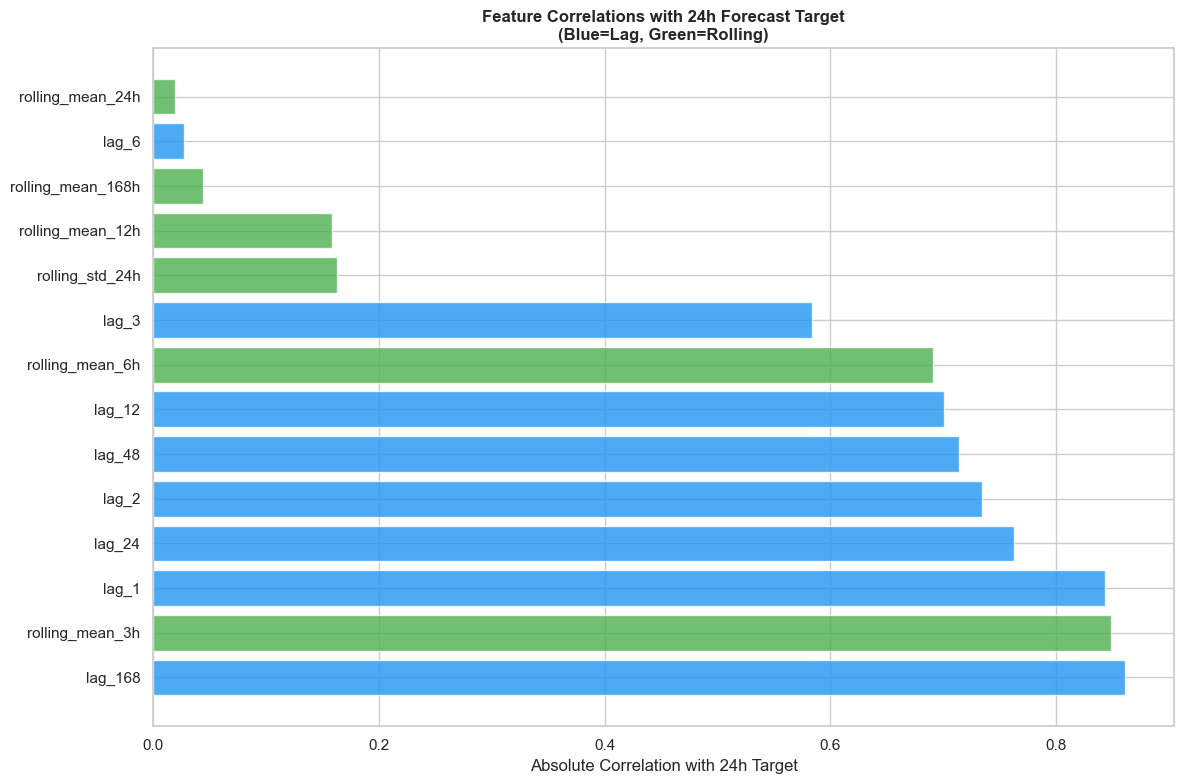


Top 10 most predictive features:
  lag_168                  : r=0.8619
  rolling_mean_3h          : r=0.8495
  lag_1                    : r=0.8438
  lag_24                   : r=0.7627
  lag_2                    : r=0.7350
  lag_48                   : r=0.7147
  lag_12                   : r=0.7012
  rolling_mean_6h          : r=0.6916
  lag_3                    : r=0.5838
  rolling_std_24h          : r=0.1630


In [14]:
# Cell 14 — Feature correlation with target
print("Computing feature correlations "
      "with target...")

# Convert to pandas for visualization
features_pdf = df_features_clean\
    .select(
        lag_cols +
        rolling_cols +
        ['target_trip_count_24h']
    ).toPandas()

# Correlation with target
corr_with_target = features_pdf\
    .corr()['target_trip_count_24h']\
    .drop('target_trip_count_24h')\
    .abs()\
    .sort_values(ascending=False)

plt.figure(figsize=(12, 8))
colors = ['#2196F3' if 'lag' in c
          else '#4CAF50'
          for c in corr_with_target.index]

plt.barh(
    corr_with_target.index[:20],
    corr_with_target.values[:20],
    color=colors[:20], alpha=0.8)
plt.xlabel('Absolute Correlation with '
           '24h Target')
plt.title('Feature Correlations with '
          '24h Forecast Target\n'
          '(Blue=Lag, Green=Rolling)',
          fontweight='bold')
plt.tight_layout()
plt.savefig(
    '../logs/feature_correlations.png',
    dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 most predictive features:")
for feat, corr in corr_with_target\
        .head(10).items():
    print(f"  {feat:<25}: r={corr:.4f}")

In [15]:
# Cell 15 — Temporal train/val/test split
print("Creating temporal train/val/test split...")
print("""
WHY TEMPORAL SPLIT (not random):
─────────────────────────────────────────────
For time-series forecasting, random split
causes data leakage:

Random split: future data in training set
→ Model sees next week's data while
  learning to predict it
→ Artificially inflated metrics
→ Completely wrong in production

Temporal split: strict chronological order
→ Train on past, validate on present,
  test on future
→ Mirrors real production deployment
→ Honest evaluation of forecasting ability
─────────────────────────────────────────────
""")

# Convert to pandas for splitting
# (feature dataset is small — ~2000 rows)
df_final = df_features_clean.toPandas()
df_final['pickup_hour'] = pd.to_datetime(
    df_final['pickup_hour'])
df_final = df_final.sort_values(
    'pickup_hour').reset_index(drop=True)

total_rows = len(df_final)
train_end  = int(total_rows * 0.70)
val_end    = int(total_rows * 0.85)

df_train = df_final.iloc[:train_end]
df_val   = df_final.iloc[train_end:val_end]
df_test  = df_final.iloc[val_end:]

print(f"Total rows:   {total_rows:,}")
print(f"\nTraining set: {len(df_train):,} rows")
print(f"  From: {df_train['pickup_hour'].min()}")
print(f"  To:   {df_train['pickup_hour'].max()}")

print(f"\nValidation:   {len(df_val):,} rows")
print(f"  From: {df_val['pickup_hour'].min()}")
print(f"  To:   {df_val['pickup_hour'].max()}")

print(f"\nTest set:     {len(df_test):,} rows")
print(f"  From: {df_test['pickup_hour'].min()}")
print(f"  To:   {df_test['pickup_hour'].max()}")

Creating temporal train/val/test split...

WHY TEMPORAL SPLIT (not random):
─────────────────────────────────────────────
For time-series forecasting, random split
causes data leakage:

Random split: future data in training set
→ Model sees next week's data while
  learning to predict it
→ Artificially inflated metrics
→ Completely wrong in production

Temporal split: strict chronological order
→ Train on past, validate on present,
  test on future
→ Mirrors real production deployment
→ Honest evaluation of forecasting ability
─────────────────────────────────────────────

Total rows:   1,998

Training set: 1,398 rows
  From: 2023-01-08 00:00:00
  To:   2023-03-07 05:00:00

Validation:   300 rows
  From: 2023-03-07 06:00:00
  To:   2023-03-19 18:00:00

Test set:     300 rows
  From: 2023-03-19 19:00:00
  To:   2023-04-03 18:00:00


In [16]:
# Cell 16 — Save all splits
import os

os.makedirs('../data/features', exist_ok=True)

# Save splits locally
df_train.to_csv(
    '../data/features/train.csv',
    index=False)
df_val.to_csv(
    '../data/features/val.csv',
    index=False)
df_test.to_csv(
    '../data/features/test.csv',
    index=False)
df_final.to_csv(
    '../data/features/all_features.csv',
    index=False)

print("✅ Feature datasets saved locally")

# Upload to S3
s3 = boto3.client(
    's3',
    aws_access_key_id=os.getenv(
        'AWS_ACCESS_KEY_ID'),
    aws_secret_access_key=os.getenv(
        'AWS_SECRET_ACCESS_KEY'),
    region_name=os.getenv('AWS_DEFAULT_REGION')
)
bucket = os.getenv('S3_BUCKET_DATA')

for filename in ['train.csv', 'val.csv',
                 'test.csv',
                 'all_features.csv']:
    s3.upload_file(
        f'../data/features/{filename}',
        bucket,
        f'project2/features/{filename}'
    )
    print(f"✅ Uploaded "
          f"project2/features/{filename}")

print(f"\n✅ All feature data in S3")

✅ Feature datasets saved locally
✅ Uploaded project2/features/train.csv
✅ Uploaded project2/features/val.csv
✅ Uploaded project2/features/test.csv
✅ Uploaded project2/features/all_features.csv

✅ All feature data in S3


In [17]:
# Cell 17 — Save feature engineering summary
feature_summary = {
    'total_features':   total_features,
    'total_rows':       int(after_drop),
    'train_rows':       int(len(df_train)),
    'val_rows':         int(len(df_val)),
    'test_rows':        int(len(df_test)),
    'split_ratios':     '70/15/15',
    'split_type':       'Temporal — no random shuffle',
    'target_variable':  'target_trip_count_24h',
    'forecast_horizon': '24 hours',
    'feature_groups': {
        'lag_features':     lag_cols,
        'rolling_features': rolling_cols,
        'time_features':    time_cols,
        'cyclical_features':cyclical_cols,
    },
    'top_features_by_correlation':
        corr_with_target.head(5)\
        .to_dict(),
    'key_decisions': [
        'Lag-24 and lag-168 from autocorrelation',
        'Cyclical encoding for hour/day/month',
        'Temporal split prevents data leakage',
        'lead(24) creates 24h forecast target',
        'PySpark Window functions for scalability'
    ],
    's3_location': (
        f"s3://{bucket}/project2/features/"
    )
}

with open(
    '../logs/feature_summary.json', 'w'
) as f:
    json.dump(feature_summary, f, indent=4)

print("✅ Feature summary saved")
print(json.dumps(feature_summary, indent=4))

spark.stop()
print("\n✅ Spark stopped cleanly")

✅ Feature summary saved
{
    "total_features": 31,
    "total_rows": 1998,
    "train_rows": 1398,
    "val_rows": 300,
    "test_rows": 300,
    "split_ratios": "70/15/15",
    "split_type": "Temporal \u2014 no random shuffle",
    "target_variable": "target_trip_count_24h",
    "forecast_horizon": "24 hours",
    "feature_groups": {
        "lag_features": [
            "lag_1",
            "lag_2",
            "lag_3",
            "lag_6",
            "lag_12",
            "lag_24",
            "lag_48",
            "lag_168"
        ],
        "rolling_features": [
            "rolling_mean_3h",
            "rolling_mean_6h",
            "rolling_mean_12h",
            "rolling_mean_24h",
            "rolling_std_24h",
            "rolling_mean_168h"
        ],
        "time_features": [
            "hour_of_day",
            "day_of_week",
            "day_of_month",
            "week_of_year",
            "month",
            "is_weekend",
            "is_rush_hour",
           